# Why Iceberg for Gold? A Tutorial

This notebook explains **why** we use Apache Iceberg for the gold layer and how to work with it.

**Prerequisites:** Silver data in MinIO, embeddings generated (run `gold_layer_tutorial.ipynb` or `python -m src.features.embedding_job`).

## 1. Parquet vs Iceberg: What's the difference?

| Aspect | Plain Parquet | Iceberg Table |
|--------|---------------|---------------|
| Storage | Single or many `.parquet` files | Parquet data + metadata layer |
| Versioning | None | Snapshot history, time travel |
| ACID | No | Yes (atomic commits) |
| Schema evolution | Manual | Add/drop/rename columns safely |
| Concurrent writes | Risk of corruption | Safe |
| Query engines | Spark, DuckDB, etc. | Spark, Trino, Flink, DuckDB, etc. |

## 2. Why Iceberg for Gold?

The gold layer holds **model-ready** data (text + embeddings + labels). We use Iceberg because:

1. **ACID transactions** – Re-running the embedding job appends safely; no risk of partial overwrites.
2. **Time travel** – Compare current vs previous snapshots (e.g., before switching BERT models).
3. **Schema evolution** – Add `split` (train/val/test) or new embedding columns without rewriting data.
4. **Ecosystem** – Spark, Trino, and other engines can query the same table.
5. **Efficient metadata** – Manifest files enable fast partition pruning and planning.

## 3. Our Iceberg Setup

- **Catalog:** SqlCatalog (SQLite for metadata, no extra services)
- **Warehouse:** MinIO (`s3://text-ml-data/iceberg`)
- **Table:** `imdb.gold` (id, text, label, embedding)

In [ ]:
!pip install pyiceberg sqlalchemy s3fs

## 4. Write gold to Iceberg

Run the embedding job with `--iceberg` to write to an Iceberg table instead of raw Parquet:

In [6]:
# Run embedding job from Python (same process = same catalog as load step below)
from src.features.embedding_job import run_embedding_job
n = run_embedding_job(iceberg=True)
if n == 0:
    print("No silver data found. Creating demo table for tutorial...")
    from src.utils.iceberg_catalog import get_iceberg_catalog
    from pyiceberg.schema import Schema
    from pyiceberg.types import FloatType, ListType, LongType, NestedField, StringType
    import pyarrow as pa
    catalog = get_iceberg_catalog()
    catalog.create_namespace_if_not_exists("imdb")
    schema = Schema(
        NestedField(1, "id", StringType(), required=True),
        NestedField(2, "text", StringType(), required=True),
        NestedField(3, "label", LongType(), required=True),
        NestedField(4, "embedding", ListType(element_id=5, element_type=FloatType(), element_required=False), required=True),
    )
    tbl = catalog.create_table("imdb.gold", schema=schema)
    import numpy as np
    demo = pa.table(
        {"id": ["demo1"], "text": ["great movie"], "label": [1], "embedding": [np.zeros(768, dtype="float32").tolist()]},
        schema=pa.schema([
            pa.field("id", pa.string(), nullable=False),
            pa.field("text", pa.string(), nullable=False),
            pa.field("label", pa.int64(), nullable=False),
            pa.field("embedding", pa.list_(pa.float32()), nullable=False),
        ]),
    )
    tbl.append(demo)
    print("Created imdb.gold with 1 demo row.")

Appended 25002 records to Iceberg table imdb.gold


In [7]:
import os
from pathlib import Path
print(Path.cwd())
print((Path.cwd() / "iceberg_catalog" / "catalog.db").exists())

c:\Users\dyh\Dropbox\Job Search\projects\text-ml-platform
True


## 5. Load and inspect the Iceberg table

Read the `imdb.gold` table and check snapshots (time travel).

In [8]:
from src.utils.iceberg_catalog import get_iceberg_catalog

catalog = get_iceberg_catalog()
table = catalog.load_table("imdb.gold")

print("Snapshots (time travel):")
for s in table.metadata.snapshots:
    print(f"  - snapshot_id={s.snapshot_id}, timestamp={s.timestamp_ms}")

df = table.scan().to_pandas()
print(f"\nRows: {len(df)}, columns: {list(df.columns)}")
print(df[["id", "label",  'embedding']].head())

Snapshots (time travel):
  - snapshot_id=5857498958613530942, timestamp=1773714328713
  - snapshot_id=2530716088029292387, timestamp=1773722444265

Rows: 25102, columns: ['id', 'text', 'label', 'embedding']
   id  label                                          embedding
0  50      1  [-0.5113769, -0.40527493, -0.9350562, 0.169289...
1  51      1  [-0.6147351, -0.5514393, -0.9734456, 0.5508812...
2  52      0  [-0.66831917, -0.3464749, -0.9575992, 0.384265...
3  53      1  [-0.45287606, -0.7145901, -0.9976316, 0.325262...
4  54      1  [-0.686058, -0.32300535, -0.7144082, 0.4404778...


## 6. Time travel example

Read the table as of a specific snapshot (e.g., the previous version):

In [ ]:
from src.features.embedding_job import run_embedding_job
run_embedding_job(iceberg=True)

In [9]:
# Reload table to pick up new snapshots from the embedding job cell above
table = catalog.load_table("imdb.gold")
# print(f"Total snapshots: {len(table.metadata.snapshots)}")
# if len(table.metadata.snapshots) >= 2:
#     prev = table.metadata.snapshots[-2]
#     try:
#         df_prev = table.scan(snapshot_id=prev.snapshot_id).to_pandas()
#         print(f"Previous snapshot had {len(df_prev)} rows")
#     except Exception as e:
#         print(f"Time travel: {e}")
# else:
#     print("Only one snapshot; run embedding_job --iceberg again to add snapshots.")

## 7. Summary

- **Use Parquet** when you need a one-off export or minimal setup.
- **Use Iceberg** when you want ACID, time travel, schema evolution, and multi-engine compatibility.

For our gold layer, Iceberg gives us a reliable, queryable table format that scales as the platform grows.

Exported 25102 rows to gold_pca_for_tableau.csv (PCA variance: 68.49%)


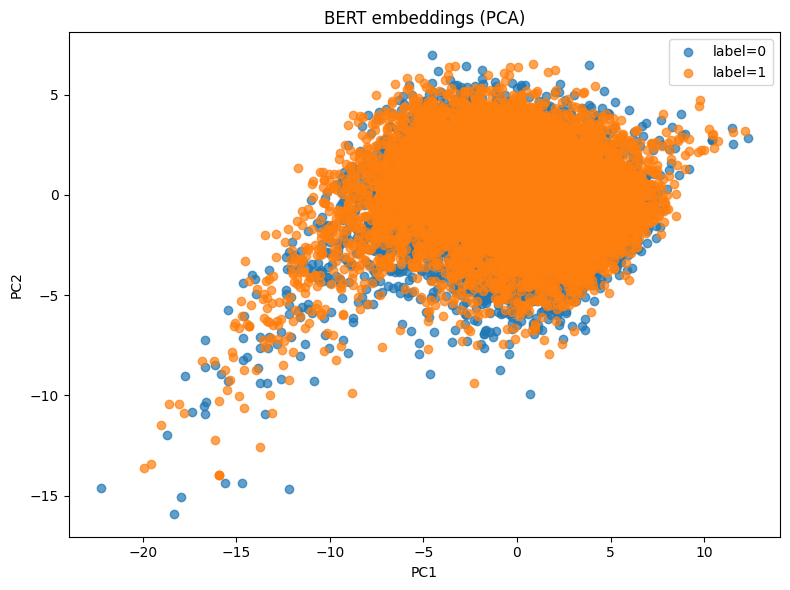

In [ ]:
# PCA + export for Tableau/Power BI + scatter preview
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.decomposition import PCA
# do t-sne decomposition

df = table.scan().to_pandas()
embeddings = np.stack(df["embedding"].apply(lambda x: np.array(x)))
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

out = pd.DataFrame({
    "id": df["id"], "pc1": coords[:, 0], "pc2": coords[:, 1],
    "label": df["label"], "text": df["text"].str[:100],
})
out.to_csv("gold_pca_for_tableau.csv", index=False)
print(f"Exported {len(out)} rows to gold_pca_for_tableau.csv (PCA variance: {pca.explained_variance_ratio_.sum():.2%})")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
for lbl in [0, 1]:
    mask = out["label"] == lbl
    plt.scatter(out.loc[mask, "pc1"], out.loc[mask, "pc2"], label=f"label={lbl}", alpha=0.7)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.title("BERT embeddings (PCA)")
plt.tight_layout(); plt.show()

In [11]:
table.scan().to_pandas()["label"].value_counts()


label
1    12565
0    12537
Name: count, dtype: int64

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = embeddings  # shape (n_samples, 768)
y = df["label"]      # 0/1

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)
pred = clf.predict(X)
print("Train accuracy:", accuracy_score(y, pred))

Train accuracy: 0.8732770297187475
